In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv('train.csv')

In [44]:
# head
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
# tail
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [47]:
df.shape

(891, 12)

In [54]:
# numeric columns for correlation
numericdf= df.select_dtypes(include=['number'])
c = numericdf.corr()
c


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

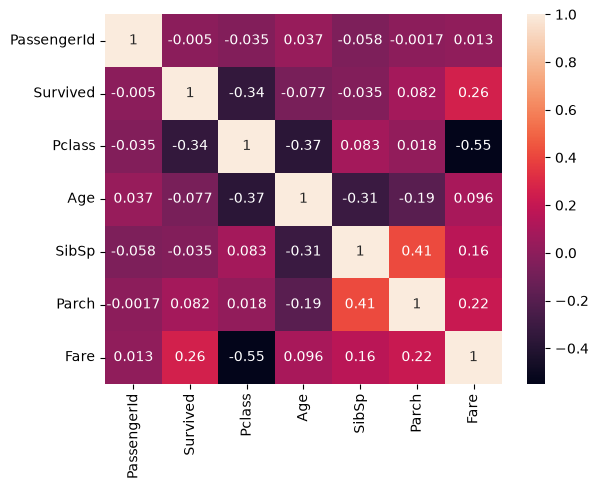

In [55]:
sns.heatmap(c, annot=True)

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [59]:
# describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [60]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [61]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [62]:
# df.fillna()
df['Age'] = df['Age'].fillna(df['Age'].median())

In [63]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [64]:
df['Cabin'] = df['Cabin'].fillna("Unknown")

In [65]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [66]:
df['Embarked'] = df['Embarked'].fillna("Unknown")

In [67]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [68]:
# Data Analysis:
# gender wise survived count
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [69]:
# Pclass wise survival rate
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [70]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [71]:
df.groupby('Sex')['SibSp'].value_counts()

Sex     SibSp
female  0        174
        1        106
        2         13
        3         11
        4          6
        8          3
        5          1
male    0        434
        1        103
        2         15
        4         12
        3          5
        5          4
        8          4
Name: count, dtype: int64

In [72]:
df.groupby('Sex')['Parch'].value_counts()

Sex     Parch
female  0        194
        1         60
        2         49
        5          4
        3          4
        4          2
        6          1
male    0        484
        1         58
        2         31
        4          2
        5          1
        3          1
Name: count, dtype: int64

In [74]:
df.groupby('Sex')['Parch'].mean() * 100

Sex
female    64.968153
male      23.570191
Name: Parch, dtype: float64

In [75]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C          0.553571
Q          0.389610
S          0.336957
Unknown    1.000000
Name: Survived, dtype: float64

In [76]:
df.groupby('Embarked')['Survived'].value_counts()

Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           217
Unknown   1             2
Name: count, dtype: int64

In [93]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

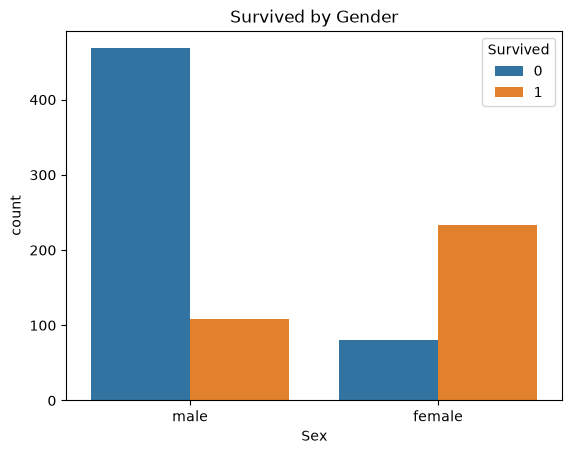

In [77]:
# GENDER VS SURVIVAL
sns.countplot(x='Sex',hue='Survived',data=df)
plt.title("Survived by Gender")
plt.show()

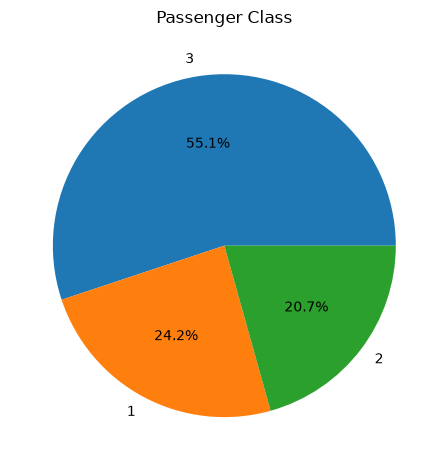

In [94]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%1.1f%%')

plt.title('Passenger Class')
plt.tight_layout()
plt.show()

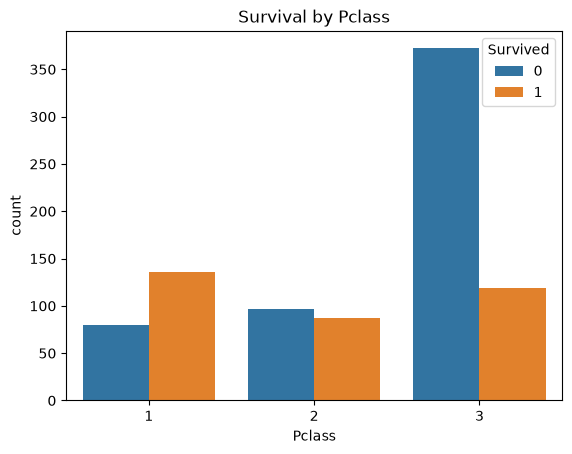

In [92]:
# passenger vs. survival
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title("Survival by Pclass")
plt.show()

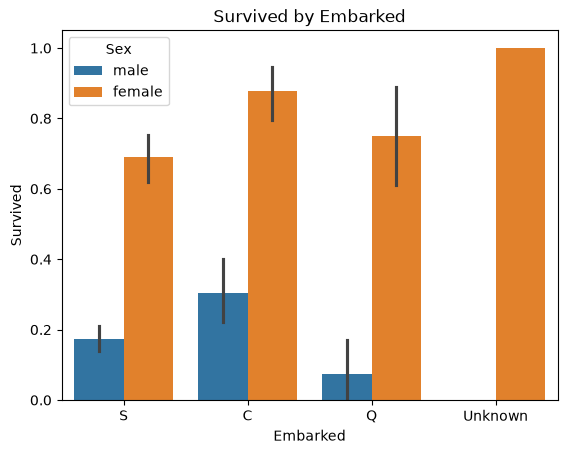

In [80]:
sns.barplot(x='Embarked',y='Survived',hue='Sex',data=df)
plt.title('Survived by Embarked')
plt.xlabel('Embarked')
plt.ylabel('Survived')
plt.show()

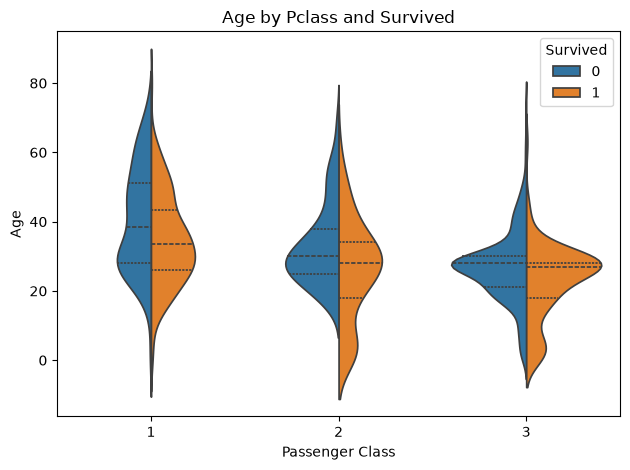

In [82]:
# Pclass and Age
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True, inner='quartile')
plt.title('Age by Pclass and Survived')
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

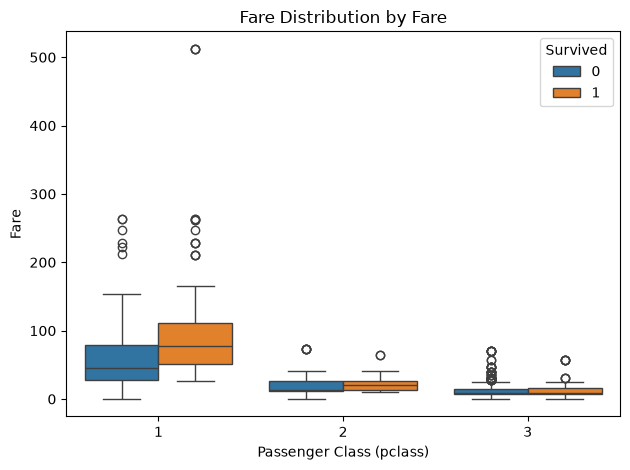

In [83]:
# Box Plot
# pclass and Fare
sns.boxplot(x='Pclass',y='Fare',hue='Survived',data=df)
plt.title("Fare Distribution by Fare")
plt.xlabel("Passenger Class (pclass)")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

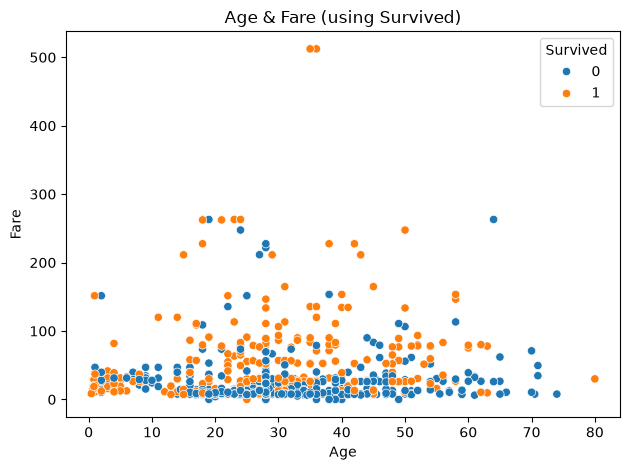

In [84]:
# Scatter plot (age,fare)
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=df)
plt.title("Age & Fare (using Survived)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()


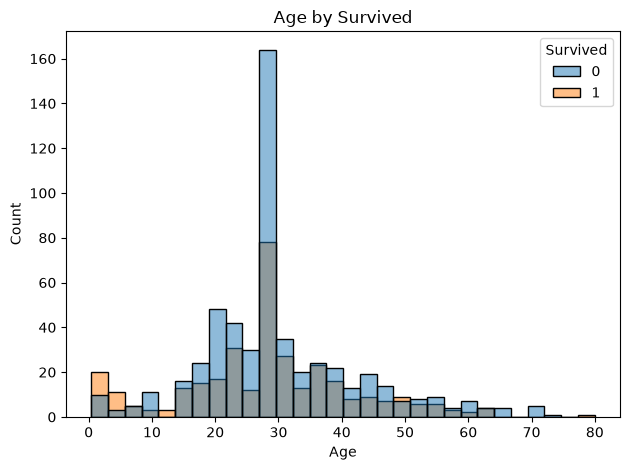

In [88]:
# Histplot
sns.histplot(data=df,x='Age',hue='Survived')
plt.title("Age by Survived")
plt.tight_layout()
plt.show()

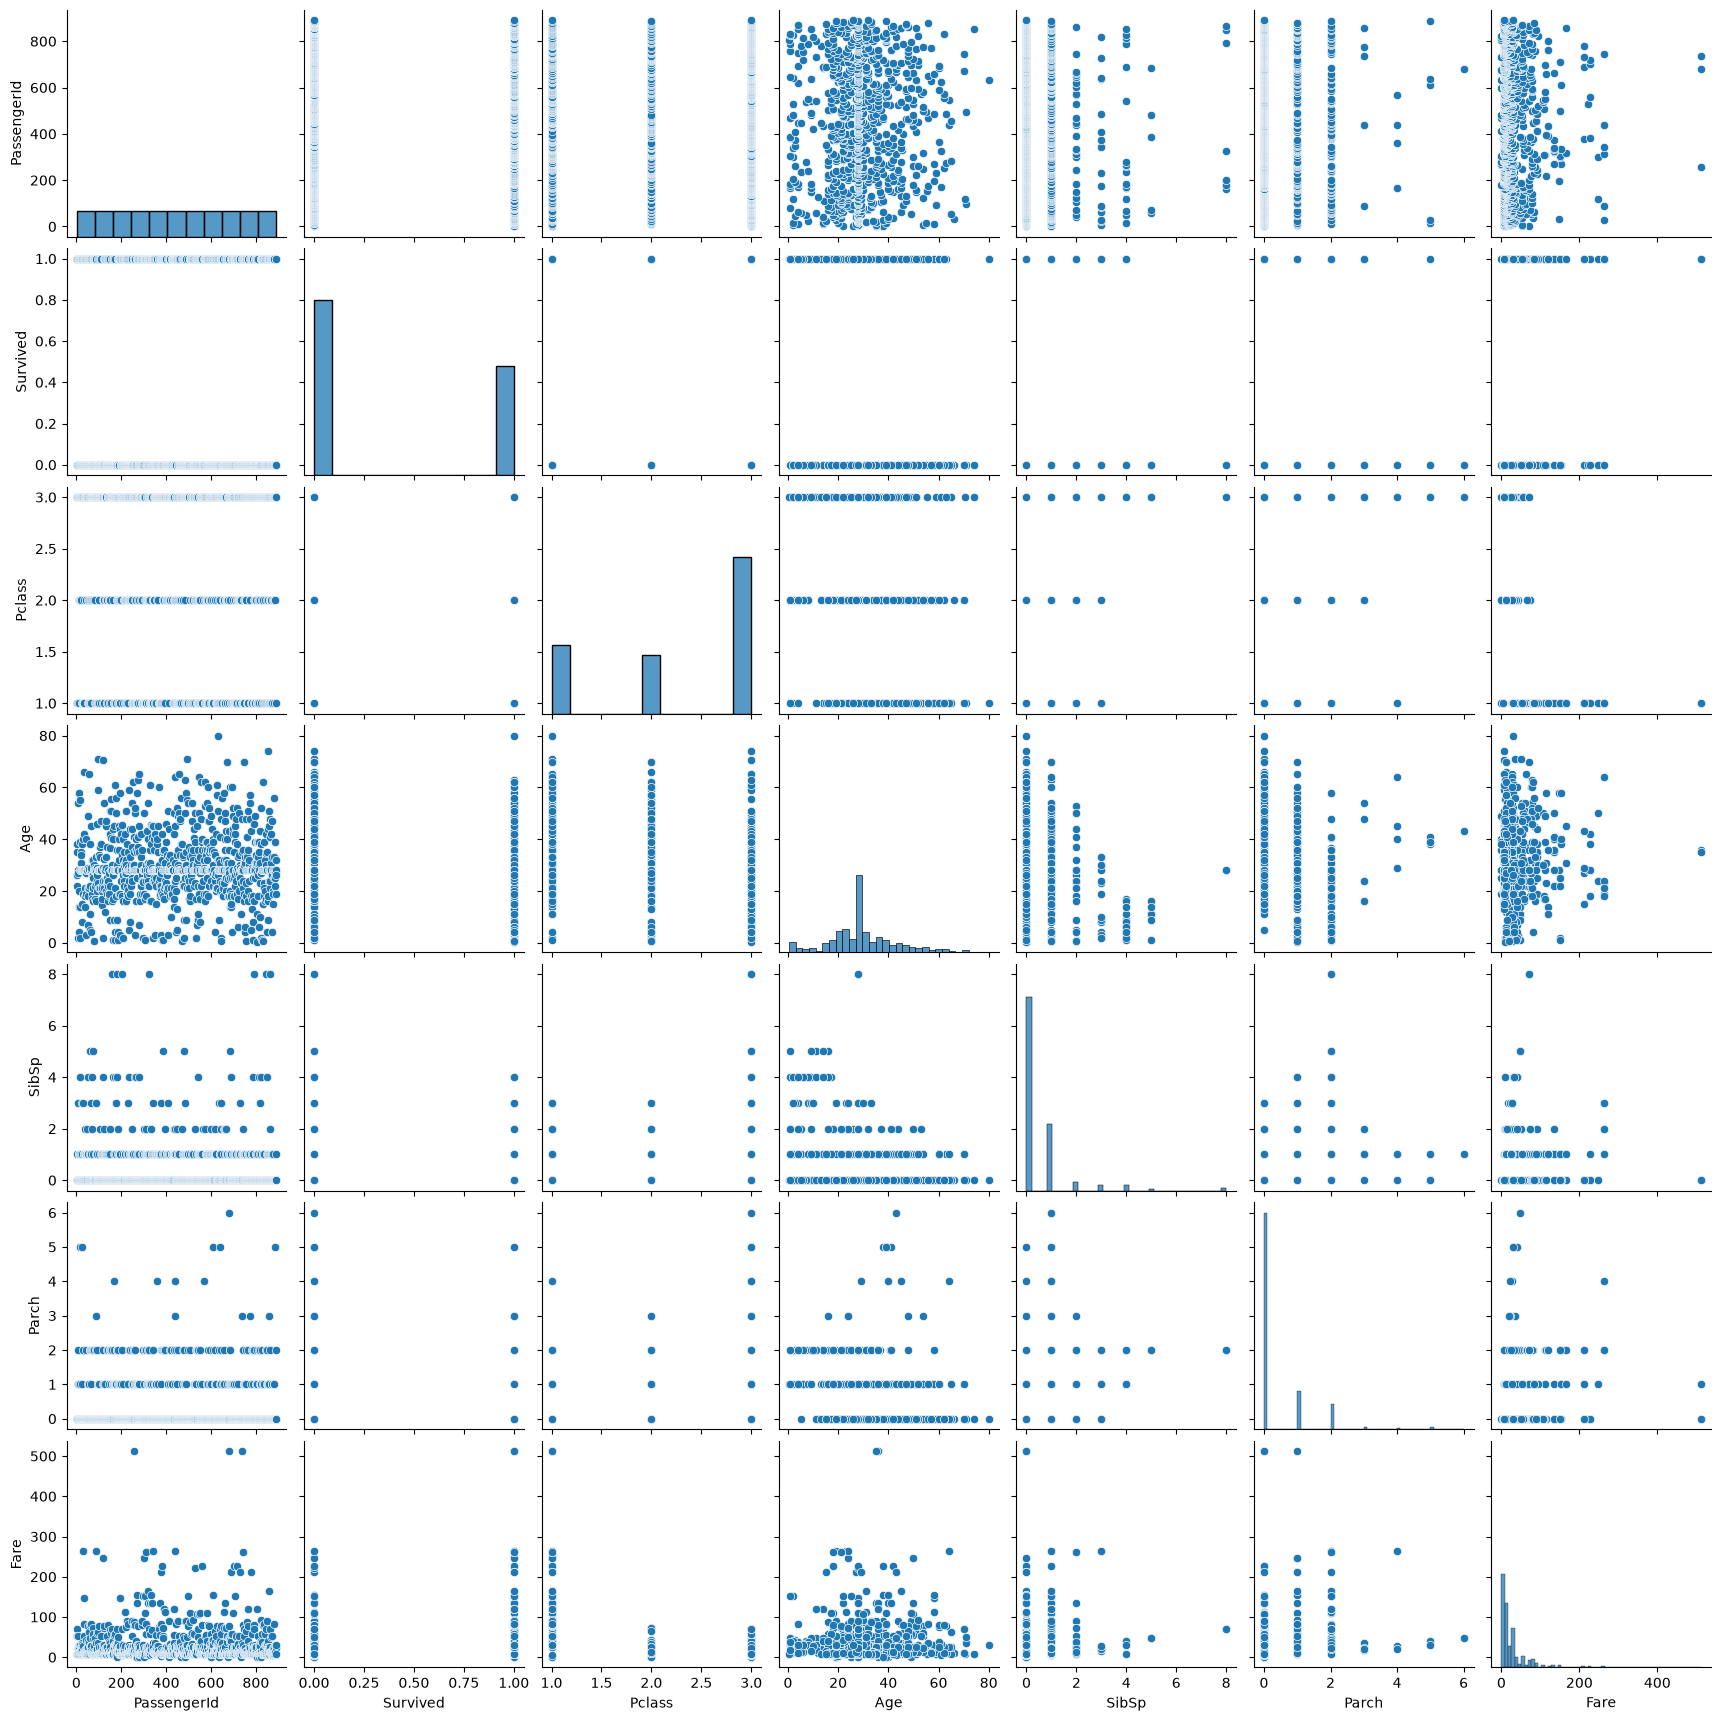

In [89]:
# Pairplot
sns.pairplot(df)

C:\Users\margi\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 26.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\margi\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 28.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


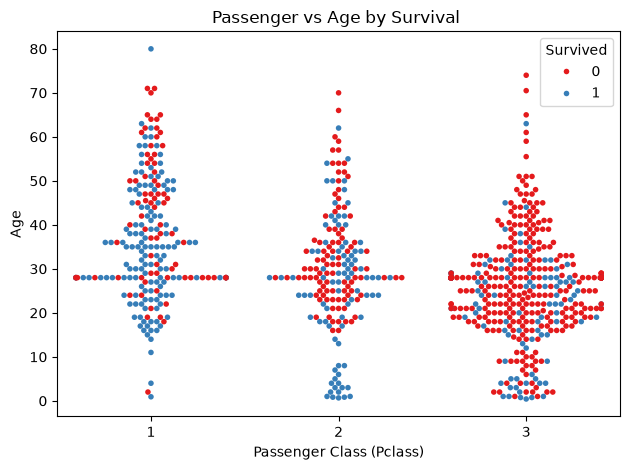

In [90]:
sns.swarmplot(x='Pclass', y='Age', hue='Survived', data=df, size=4,
              palette='Set1')

plt.title('Passenger vs Age by Survival ')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()